# Milestone 2 - IT Support Analytics
## Modules 3 & 4

Week 3-4 deliverables

In [111]:
# Milestone 2: Exploratory Visualization and Cluster Analysis
# Modules 3 & 4: IT Support Team Performance Analysis

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set matplotlib style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')

print("="*70)
print("MILESTONE 2: EXPLORATORY VISUALIZATION AND CLUSTER INSIGHTS")
print("="*70)

MILESTONE 2: EXPLORATORY VISUALIZATION AND CLUSTER INSIGHTS


In [96]:
df = pd.read_csv('customer_support_tickets_work.csv')
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [97]:
# ============================================================================
# MODULE 3: EXPLORATORY VISUALIZATION
# ============================================================================

print("\n" + "="*70)
print("MODULE 3: EXPLORATORY VISUALIZATION")
print("="*70)


MODULE 3: EXPLORATORY VISUALIZATION


In [98]:
print(df.columns.tolist())
df.columns = df.columns.str.strip().str.replace(' ', '_')


['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']



 Creating Visualization 1: Ticket Type Distribution


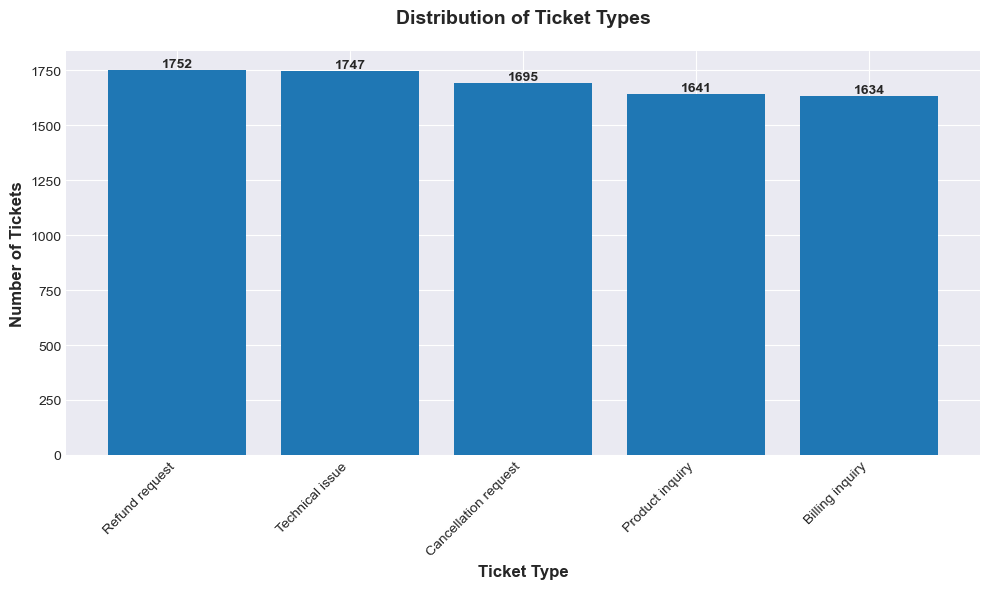


   Key Findings:
   - Refund request: 1752 tickets (20.7%)
   - Technical issue: 1747 tickets (20.6%)
   - Cancellation request: 1695 tickets (20.0%)
   - Product inquiry: 1641 tickets (19.4%)
   - Billing inquiry: 1634 tickets (19.3%)


In [99]:
# ----------------------------------------------------------------------------
# VISUALIZATION 1: Ticket Type Distribution
# ----------------------------------------------------------------------------

print("\n Creating Visualization 1: Ticket Type Distribution")

plt.figure(figsize=(10, 6))

# Count tickets by type
ticket_type_counts = df['Ticket_Type'].value_counts()

# Create bar chart
bars = plt.bar(ticket_type_counts.index, ticket_type_counts.values)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Distribution of Ticket Types', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Ticket Type', fontsize=12, fontweight='bold')
plt.ylabel('Number of Tickets', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('viz1_ticket_type_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n   Key Findings:")
for ticket_type, count in ticket_type_counts.items():
    percentage = (count / len(df)) * 100
    print(f"   - {ticket_type}: {count} tickets ({percentage:.1f}%)")


Creating Visualization 2: Top 10 Ticket Subjects


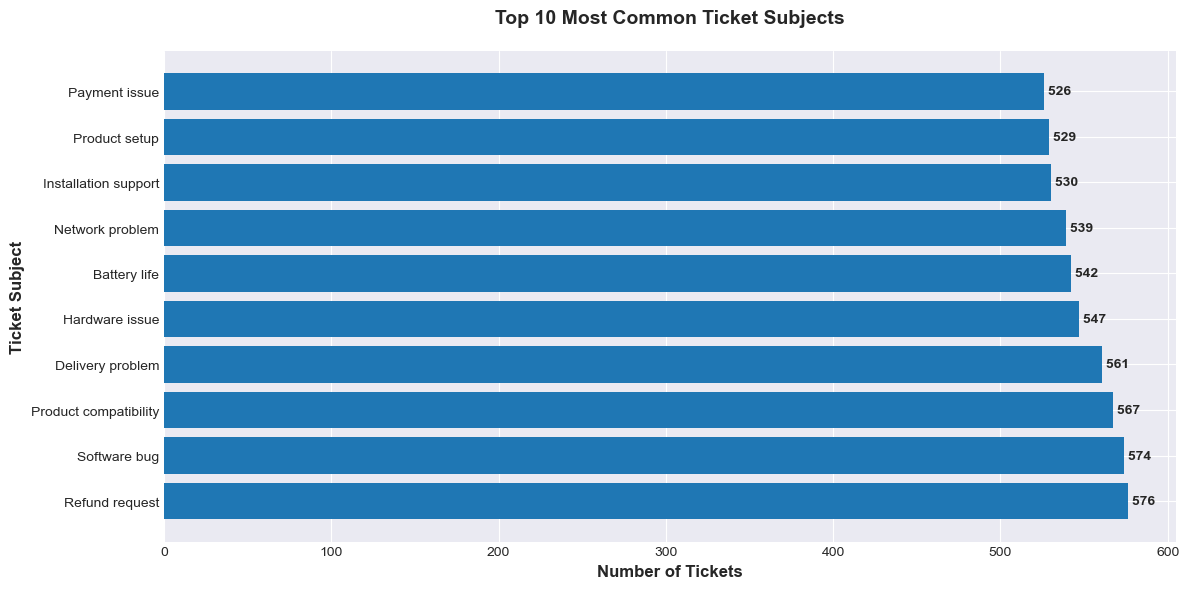

In [100]:
# ----------------------------------------------------------------------------
# VISUALIZATION 2: Top 10 Categories/Subjects
# ----------------------------------------------------------------------------

print("\nCreating Visualization 2: Top 10 Ticket Subjects")

plt.figure(figsize=(12, 6))

# Get top 10 subjects
top_subjects = df['Ticket_Subject'].value_counts().head(10)

# Create horizontal bar chart
bars = plt.barh(range(len(top_subjects)), top_subjects.values)
                

# Add value labels
for i, (subject, count) in enumerate(top_subjects.items()):
    plt.text(count, i, f' {count}', va='center', fontsize=10, fontweight='bold')

plt.yticks(range(len(top_subjects)), top_subjects.index)
plt.title('Top 10 Most Common Ticket Subjects', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Number of Tickets', fontsize=12, fontweight='bold')
plt.ylabel('Ticket Subject', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('viz2_top_subjects.png', dpi=300, bbox_inches='tight')
plt.show()



Creating Visualization 3: Ticket Priority Distribution


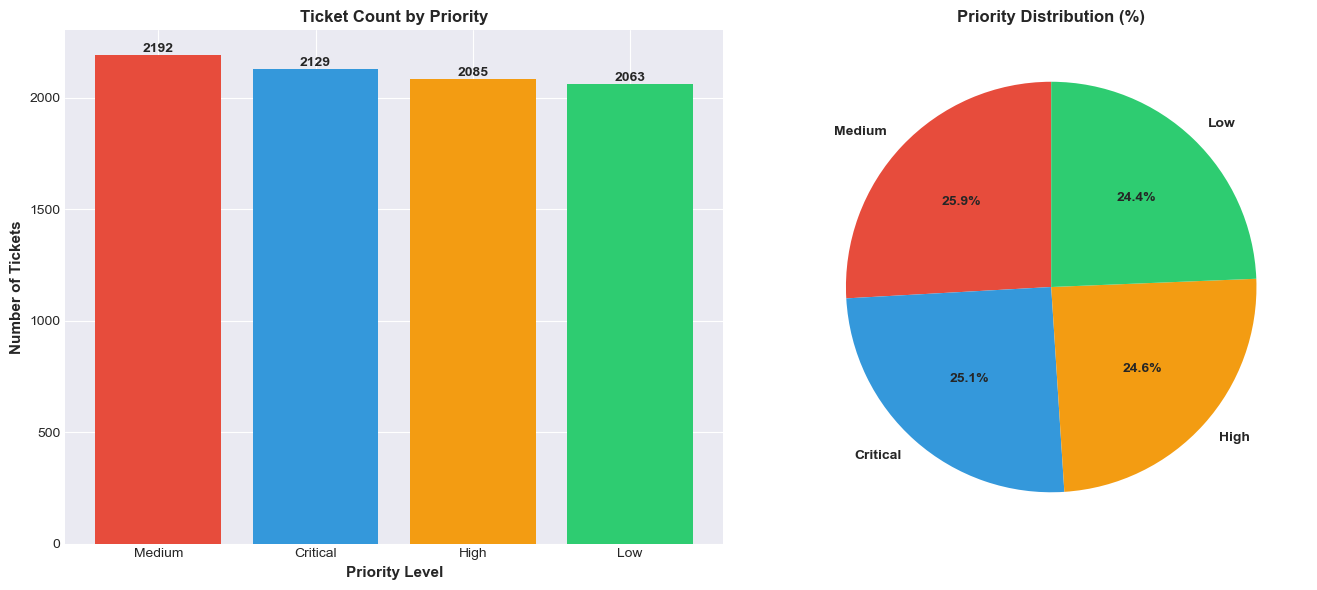

In [101]:
# ----------------------------------------------------------------------------
# VISUALIZATION 3: Ticket Priority Distribution
# ----------------------------------------------------------------------------

print("\nCreating Visualization 3: Ticket Priority Distribution")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Count tickets by priority
priority_counts = df['Ticket_Priority'].value_counts()

bars = ax1.bar(priority_counts.index, priority_counts.values, color=bar_colors)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_title('Ticket Count by Priority', fontsize=12, fontweight='bold')
ax1.set_xlabel('Priority Level', fontsize=11, fontweight='bold')
ax1.set_ylabel('Number of Tickets', fontsize=11, fontweight='bold')
ax1.tick_params(axis='x', rotation=0)

# Pie chart
ax2.pie(priority_counts.values, labels=priority_counts.index, autopct='%1.1f%%',
        colors=bar_colors, startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})
ax2.set_title('Priority Distribution (%)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('viz3_priority_distribution.png', dpi=300, bbox_inches='tight')
plt.show()




Creating Visualization 4: Ticket Status Distribution


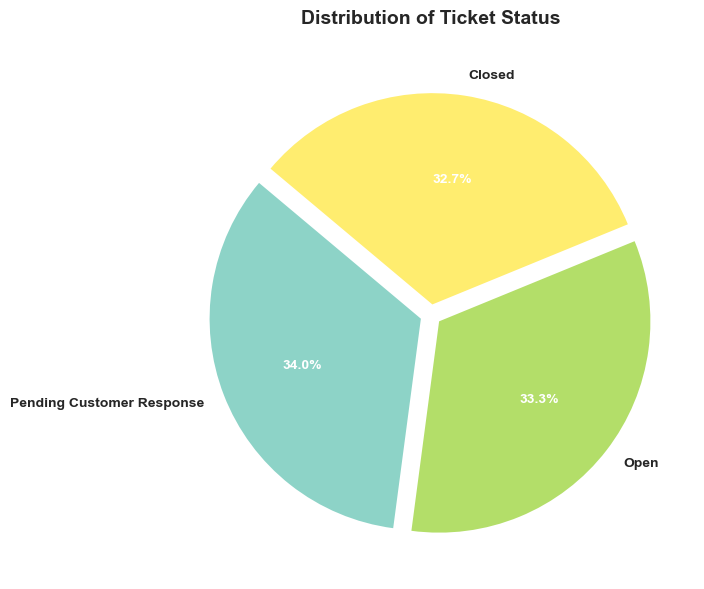

In [103]:
# ----------------------------------------------------------------------------
# VISUALIZATION 4: Ticket Status Distribution
# ----------------------------------------------------------------------------

print("\nCreating Visualization 4: Ticket Status Distribution")

plt.figure(figsize=(10, 6))

# Count tickets by status
status_counts = df['Ticket_Status'].value_counts()

# Create pie chart with custom colors
colors_status = plt.cm.Set3(np.linspace(0, 1, len(status_counts)))

wedges, texts, autotexts = plt.pie(status_counts.values, 
                                     labels=status_counts.index,
                                     autopct='%1.1f%%',
                                     colors=colors_status,
                                     startangle=140,
                                     explode=[0.05] * len(status_counts))

# Make percentage text bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

# Make labels bold
for text in texts:
    text.set_fontweight('bold')
    text.set_fontsize(10)

plt.title('Distribution of Ticket Status', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('viz4_status_distribution.png', dpi=300, bbox_inches='tight')
plt.show()



Creating Visualization 5: Tickets by Channel


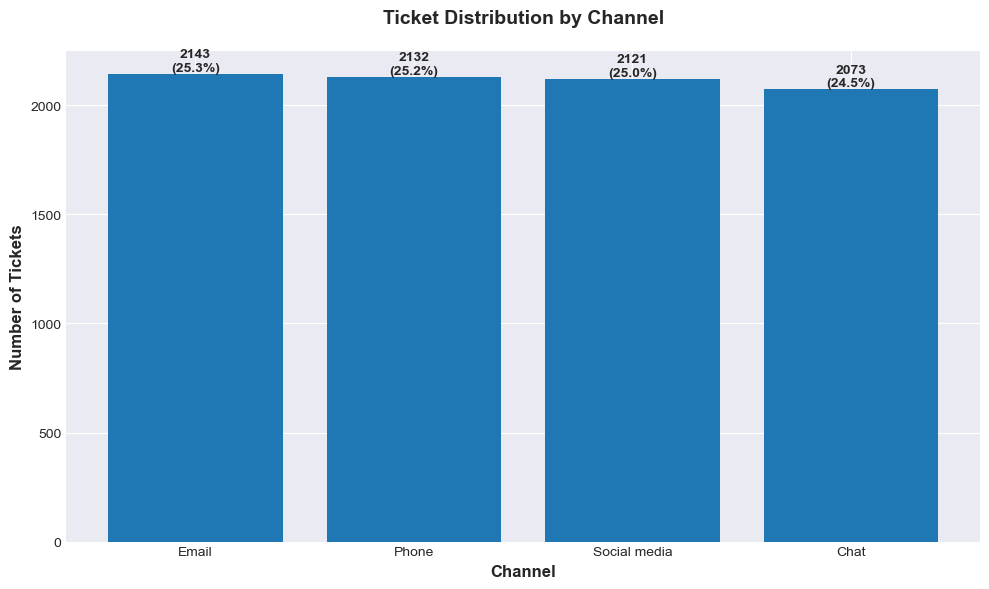

In [104]:
# ----------------------------------------------------------------------------
# VISUALIZATION 5: Tickets by Channel
# ----------------------------------------------------------------------------

print("\nCreating Visualization 5: Tickets by Channel")

plt.figure(figsize=(10, 6))

# Count tickets by channel
channel_counts = df['Ticket_Channel'].value_counts()

# Create bar chart
bars = plt.bar(channel_counts.index, channel_counts.values)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}\n({height/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Ticket Distribution by Channel', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Channel', fontsize=12, fontweight='bold')
plt.ylabel('Number of Tickets', fontsize=12, fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('viz5_channel_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


In [105]:
# ============================================================================
# MODULE 4: SIMILARITY AND CLUSTER INSIGHTS
# ============================================================================

print("\n" + "="*70)
print("MODULE 4: SIMILARITY AND CLUSTER INSIGHTS")
print("="*70)


MODULE 4: SIMILARITY AND CLUSTER INSIGHTS


In [106]:
priority_map = {
    'Low': 1,
    'Medium': 2,
    'High': 3,
    'Urgent': 4
}

df['Priority_Score'] = df['Ticket_Priority'].map(priority_map)



Creating Visualization 6: Priority Score Distribution by Ticket Type
Creating Visualization 6: Priority Score Distribution by Ticket Type


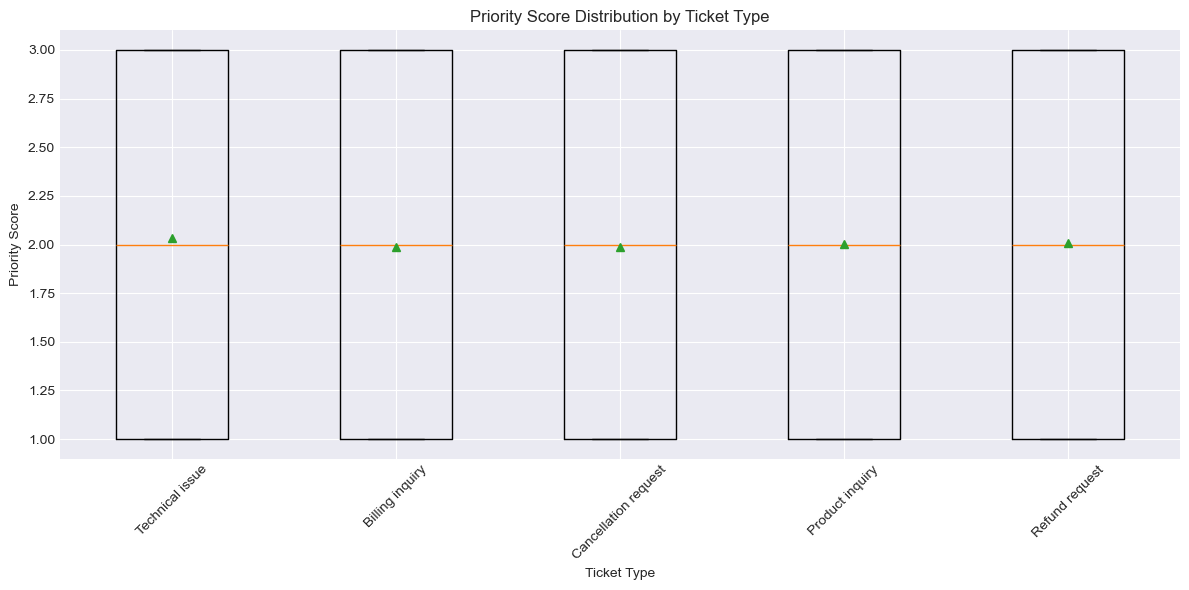


Priority Score Summary:
Technical issue → Avg: 2.03, Median: 2.0
Billing inquiry → Avg: 1.99, Median: 2.0
Cancellation request → Avg: 1.99, Median: 2.0
Product inquiry → Avg: 2.00, Median: 2.0
Refund request → Avg: 2.01, Median: 2.0


In [107]:
# ----------------------------------------------------------------------------
# VISUALIZATION 6: Priority Score Analysis (Boxplot)
# ----------------------------------------------------------------------------

print("\nCreating Visualization 6: Priority Score Distribution by Ticket Type")
# Visualization 6: Priority Score by Ticket Type (Boxplot)

print("Creating Visualization 6: Priority Score Distribution by Ticket Type")

plt.figure(figsize=(12, 6))

# Get ticket types
ticket_types = df['Ticket_Type'].unique()

# Prepare data
data = [
    df[df['Ticket_Type'] == t]['Priority_Score'].dropna()
    for t in ticket_types
]

# Boxplot
plt.boxplot(data, labels=ticket_types, showmeans=True)

plt.title("Priority Score Distribution by Ticket Type")
plt.xlabel("Ticket Type")
plt.ylabel("Priority Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Summary stats
print("\nPriority Score Summary:")
for t in ticket_types:
    scores = df[df['Ticket_Type'] == t]['Priority_Score']
    print(f"{t} → Avg: {scores.mean():.2f}, Median: {scores.median():.1f}")


Creating Visualization 7: Customer Satisfaction by Priority


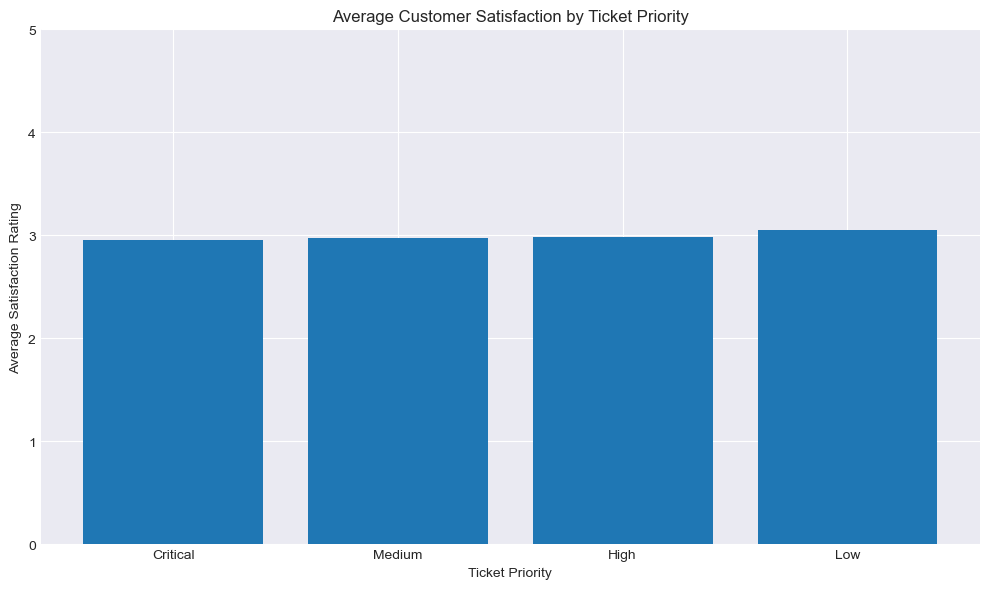

In [108]:
# Visualization 7: Customer Satisfaction by Priority

print("Creating Visualization 7: Customer Satisfaction by Priority")

plt.figure(figsize=(10, 6))

# Remove missing ratings
df_satisfaction = df[df['Customer_Satisfaction_Rating'].notna()]

# Average satisfaction by priority
avg_satisfaction = (
    df_satisfaction
    .groupby('Ticket_Priority')['Customer_Satisfaction_Rating']
    .mean()
    .sort_values()
)

# Bar chart
plt.bar(avg_satisfaction.index, avg_satisfaction.values)

plt.title("Average Customer Satisfaction by Ticket Priority")
plt.xlabel("Ticket Priority")
plt.ylabel("Average Satisfaction Rating")
plt.ylim(0, 5)
plt.tight_layout()
plt.show()



 Creating Visualization 8: Priority Score vs Customer Satisfaction


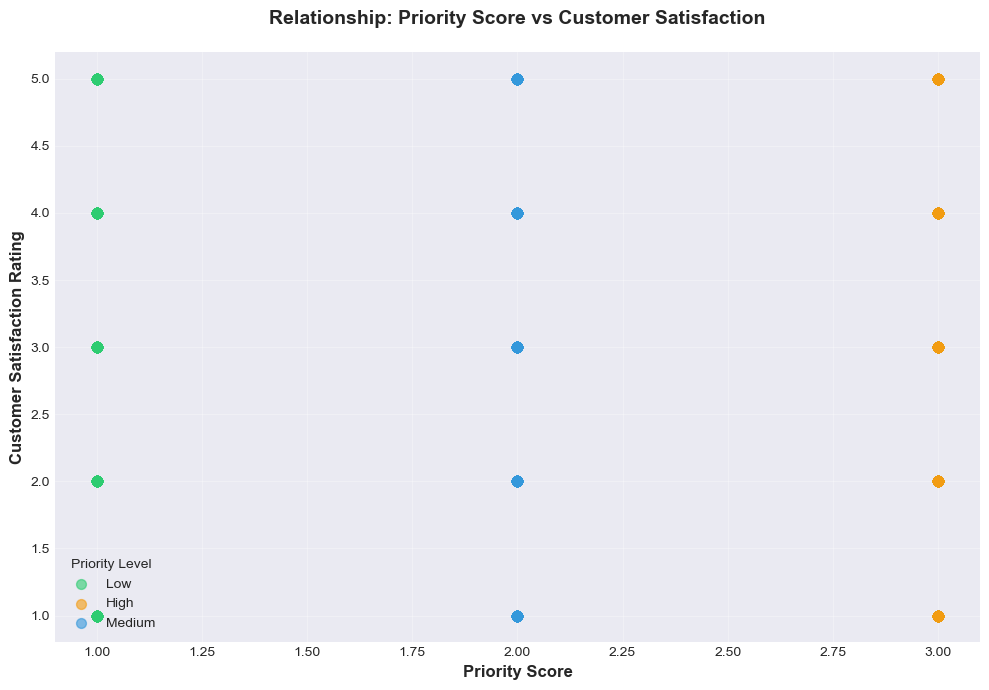


 Correlation between Priority Score and Satisfaction: -0.020


In [109]:
# ----------------------------------------------------------------------------
# VISUALIZATION 8: Scatter Plot - Priority Score vs Satisfaction
# ----------------------------------------------------------------------------

print("\n Creating Visualization 8: Priority Score vs Customer Satisfaction")

plt.figure(figsize=(10, 7))

# Filter data with both values
df_scatter = df[(df['Customer_Satisfaction_Rating'].notna()) & 
                (df['Priority_Score'].notna())]

# Create scatter plot with different colors for each priority level
priority_levels = df_scatter['Ticket_Priority'].unique()
colors_scatter = {'critical': '#e74c3c', 'high': '#f39c12', 
                  'medium': '#3498db', 'low': '#2ecc71'}

for priority in priority_levels:
    data = df_scatter[df_scatter['Ticket_Priority'] == priority]
    plt.scatter(data['Priority_Score'], 
               data['Customer_Satisfaction_Rating'],
               alpha=0.6, 
               s=50,
               color=colors_scatter.get(priority.lower(), '#95a5a6'),
               label=priority.capitalize())

plt.title('Relationship: Priority Score vs Customer Satisfaction', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Priority Score', fontsize=12, fontweight='bold')
plt.ylabel('Customer Satisfaction Rating', fontsize=12, fontweight='bold')
plt.legend(title='Priority Level', loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('viz8_priority_vs_satisfaction_scatter.png', dpi=300, bbox_inches='tight')
plt.show()


# Calculate correlation
correlation = df_scatter['Priority_Score'].corr(df_scatter['Customer_Satisfaction_Rating'])
print(f"\n Correlation between Priority Score and Satisfaction: {correlation:.3f}")

In [110]:
# ============================================================================
# SUMMARY OF KEY PATTERNS
# ============================================================================

print("\n" + "="*70)
print("📋 SUMMARY OF KEY PATTERNS AND INSIGHTS")
print("="*70)

print("\n1️⃣ TICKET TYPE ANALYSIS:")
print(f"   - Most common ticket type: {ticket_type_counts.index[0]} ({ticket_type_counts.values[0]} tickets)")
print(f"   - Least common ticket type: {ticket_type_counts.index[-1]} ({ticket_type_counts.values[-1]} tickets)")

print("\n2️⃣ PRIORITY DISTRIBUTION:")
total_critical_high = priority_counts.get('Critical', 0) + priority_counts.get('High', 0)
percentage_urgent = (total_critical_high / len(df)) * 100
print(f"   - Critical + High priority tickets: {total_critical_high} ({percentage_urgent:.1f}%)")
print(f"   - This indicates the urgency level of incoming support requests")

print("\n3️⃣ CHANNEL PERFORMANCE:")
print(f"   - Most used channel: {channel_counts.index[0]} ({channel_counts.values[0]} tickets)")
print(f"   - Least used channel: {channel_counts.index[-1]} ({channel_counts.values[-1]} tickets)")

print("\n4️⃣ CUSTOMER SATISFACTION:")
if len(df_satisfaction) > 0:
    avg_satisfaction = df_satisfaction['Customer_Satisfaction_Rating'].mean()
    print(f"   - Overall average satisfaction: {avg_satisfaction:.2f}/5.0")
    print(f"   - Satisfaction ratings available for {len(df_satisfaction)} tickets")
else:
    print("   - No satisfaction ratings available in dataset")

print("\n5️⃣ STATUS OVERVIEW:")
closed_count = status_counts.get('Closed', 0)
closed_percentage = (closed_count / len(df)) * 100 if len(df) > 0 else 0
print(f"   - Closed tickets: {closed_count} ({closed_percentage:.1f}%)")
print(f"   - This shows the resolution rate of support team")

print("\n" + "="*70)
print("✅ MILESTONE 2 COMPLETED SUCCESSFULLY!")
print("="*70)
print("\n📁 Generated Visualizations:")
print("   1. viz1_ticket_type_distribution.png")
print("   2. viz2_top_subjects.png")
print("   3. viz3_priority_distribution.png")
print("   4. viz4_status_distribution.png")
print("   5. viz5_channel_distribution.png")
print("   6. viz6_priority_score_boxplot.png")
print("   7. viz7_satisfaction_by_priority.png")
print("   8. viz8_priority_vs_satisfaction_scatter.png")
print("\n💡 Next Steps: Use these insights for Milestone 3 performance analysis")
print("="*70)


📋 SUMMARY OF KEY PATTERNS AND INSIGHTS

1️⃣ TICKET TYPE ANALYSIS:
   - Most common ticket type: Refund request (1752 tickets)
   - Least common ticket type: Billing inquiry (1634 tickets)

2️⃣ PRIORITY DISTRIBUTION:
   - Critical + High priority tickets: 4214 (49.8%)
   - This indicates the urgency level of incoming support requests

3️⃣ CHANNEL PERFORMANCE:
   - Most used channel: Email (2143 tickets)
   - Least used channel: Chat (2073 tickets)

4️⃣ CUSTOMER SATISFACTION:
   - Overall average satisfaction: 2.99/5.0
   - Satisfaction ratings available for 2769 tickets

5️⃣ STATUS OVERVIEW:
   - Closed tickets: 2769 (32.7%)
   - This shows the resolution rate of support team

✅ MILESTONE 2 COMPLETED SUCCESSFULLY!

📁 Generated Visualizations:
   1. viz1_ticket_type_distribution.png
   2. viz2_top_subjects.png
   3. viz3_priority_distribution.png
   4. viz4_status_distribution.png
   5. viz5_channel_distribution.png
   6. viz6_priority_score_boxplot.png
   7. viz7_satisfaction_by_priori